In [1]:
import pandas as pd
titanic=pd.read_csv('Titanic_train.csv')

In [2]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
titanic=titanic.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)

In [20]:
age_mean=titanic['Age'].mean()

In [21]:
age_mean

29.69911764705882

In [22]:
titanic['Age']=titanic['Age'].fillna(age_mean)

In [23]:
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


In [25]:
Embarked_mode=titanic['Embarked'].mode()[0]

In [26]:
titanic['Embarked']=titanic['Embarked'].fillna(Embarked_mode)

In [27]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [28]:
titanic=pd.get_dummies(titanic,columns=['Sex','Embarked'],drop_first=True,dtype=int)

In [29]:
titanic

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,1,0,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,0,1
887,1,1,19.000000,0,0,30.0000,0,0,1
888,0,3,29.699118,1,2,23.4500,0,0,1
889,1,1,26.000000,0,0,30.0000,1,0,0


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=titanic.drop('Survived',axis=1)
y=titanic['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)
prediction=lr.predict(X_test_scaled)
print(f"the accuracy score of this model is : {accuracy_score(y_test,prediction)*100:.2f}%")
print(f"Classification report of this model is : \n{classification_report(y_test,prediction)}")
print(f"Confusion Matrix for this model is : {confusion_matrix(y_test,prediction)}")

the accuracy score of this model is : 81.01%
Classification report of this model is : 
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix for this model is : [[90 15]
 [19 55]]


In [42]:
from sklearn.metrics import roc_auc_score,roc_curve
y_prob=lr.predict_proba(X_test_scaled)[:,1]
auc_score=roc_auc_score(y_test,y_prob)
print(f"the roc_auc_score of this model is: {auc_score}")

the roc_auc_score of this model is: 0.8818532818532818


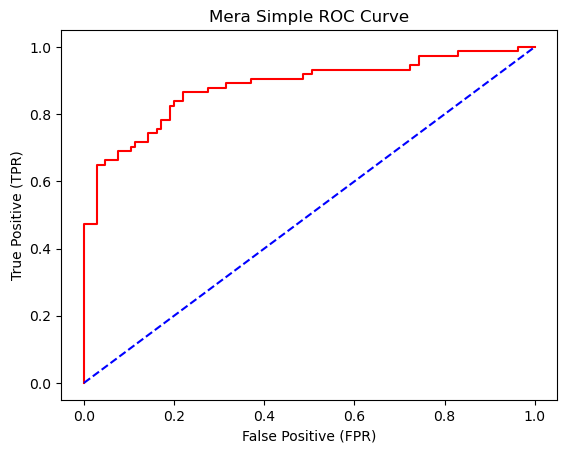

In [43]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,color='red')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--') 
plt.xlabel('False Positive (FPR)')
plt.ylabel('True Positive (TPR)')
plt.title('Mera Simple ROC Curve')
plt.show()

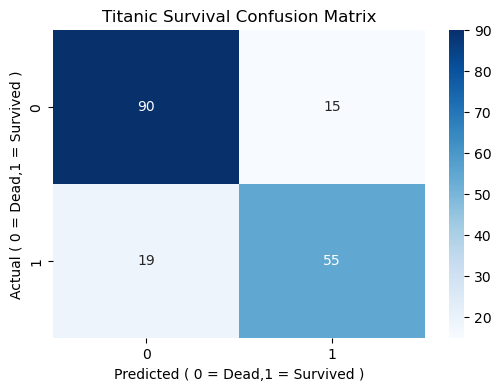

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,prediction),annot=True,fmt='d',cmap='Blues')
plt.title("Titanic Survival Confusion Matrix")
plt.xlabel('Predicted ( 0 = Dead,1 = Survived )')
plt.ylabel('Actual ( 0 = Dead,1 = Survived )')
plt.show()

In [44]:
import pandas as pd
coefficients = lr.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': coefficients
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("Model ke Coefficients (Features ki Aukaat):")
print(feature_importance)

Model ke Coefficients (Features ki Aukaat):
      Feature  Importance
4        Fare    0.124708
6  Embarked_Q   -0.039594
3       Parch   -0.099004
7  Embarked_S   -0.192275
2       SibSp   -0.351385
1         Age   -0.405537
0      Pclass   -0.788321
5    Sex_male   -1.276292


## Interpretation of Logistic Regression Coefficients

Based on the coefficients generated by our Logistic Regression model, we can interpret the significance of various features in predicting the survival probability of a passenger:

Gender Policy (Sex_male = -1.276): This is the strongest negative feature in our model. It indicates that being a male significantly decreased the chances of survival. This mathematically validates the historical "women and children first" rescue policy implemented during the disaster.

Socio-Economic Privilege (Pclass = -0.788 and Fare = +0.124): The passenger class (Pclass) has a strong negative impact, meaning passengers in lower classes (e.g., 3rd Class) had a much lower probability of surviving. Conversely, Fare is a positive feature, indicating that passengers who paid more for their tickets (wealthier individuals in 1st Class) had a higher chance of survival.

The Age Factor (Age = -0.405): Age has a negative coefficient, which means that as the age of the passenger increases, their probability of survival decreases. This shows that younger passengers, specifically children, were given priority during the rescue operations.

In [50]:
import pickle
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train) 

with open('titanic_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('titanic_scaler.pkl', 'wb') as f:
    pickle.dump(scale, f)
